In [102]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt



In [103]:
df = pd.read_csv("Data.csv")

In [104]:
df.head(2)

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Gender             30 non-null     object 
 2   Education          30 non-null     object 
 3   Experience         29 non-null     float64
 4   Department         30 non-null     object 
 5   City               30 non-null     object 
 6   Job_Level          30 non-null     object 
 7   Performance_Score  29 non-null     float64
 8   Years_at_Company   30 non-null     int64  
 9   Salary             30 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.5+ KB


In [106]:
numerical_values = df.select_dtypes(include=['int64', 'float64'])

In [107]:
categorical_values = df.select_dtypes(exclude=['int64', 'float64'])

In [108]:
df['City'].unique()

array(['Hyderabad', 'Bangalore', 'Chennai', 'Mumbai'], dtype=object)

In [109]:
df['Education'].unique() #bachelors < masters < phd
#so we have ordinal data and we should do lable encoding.

array(['Bachelors', 'Masters', 'PhD'], dtype=object)

In [110]:
x = df['Experience'].dropna()

In [111]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000
2,28,Male,Bachelors,5.0,IT,Hyderabad,Mid,3.0,4,550000
3,30,Female,Masters,7.0,Finance,Chennai,Mid,4.0,6,680000
4,35,Male,PhD,10.0,IT,Bangalore,Senior,5.0,9,950000


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Gender             30 non-null     object 
 2   Education          30 non-null     object 
 3   Experience         29 non-null     float64
 4   Department         30 non-null     object 
 5   City               30 non-null     object 
 6   Job_Level          30 non-null     object 
 7   Performance_Score  29 non-null     float64
 8   Years_at_Company   30 non-null     int64  
 9   Salary             30 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.5+ KB


In [113]:
df = df.dropna(subset=['Experience','Performance_Score'])

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                28 non-null     int64  
 1   Gender             28 non-null     object 
 2   Education          28 non-null     object 
 3   Experience         28 non-null     float64
 4   Department         28 non-null     object 
 5   City               28 non-null     object 
 6   Job_Level          28 non-null     object 
 7   Performance_Score  28 non-null     float64
 8   Years_at_Company   28 non-null     int64  
 9   Salary             28 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.4+ KB


In [115]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000
2,28,Male,Bachelors,5.0,IT,Hyderabad,Mid,3.0,4,550000
3,30,Female,Masters,7.0,Finance,Chennai,Mid,4.0,6,680000
4,35,Male,PhD,10.0,IT,Bangalore,Senior,5.0,9,950000


In [116]:
numerical_values
numerical_values.info()
nv = numerical_values.fillna(numerical_values.mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Experience         29 non-null     float64
 2   Performance_Score  29 non-null     float64
 3   Years_at_Company   30 non-null     int64  
 4   Salary             30 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.3 KB


In [117]:
cv = categorical_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      30 non-null     object
 1   Education   30 non-null     object
 2   Department  30 non-null     object
 3   City        30 non-null     object
 4   Job_Level   30 non-null     object
dtypes: object(5)
memory usage: 1.3+ KB


In [118]:
nv.isnull().sum()

,0
Age,0
Experience,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [119]:
sorted_numeric_data = nv.astype(int)

In [120]:
sorted_numeric_data

,Age,Experience,Performance_Score,Years_at_Company,Salary
0,22,1,3,1,320000
1,25,3,4,2,420000
2,28,5,3,4,550000
3,30,7,4,6,680000
4,35,10,5,9,950000
5,26,3,3,2,400000
6,40,15,4,12,1200000
7,29,6,3,5,600000
8,32,8,4,7,720000
9,45,20,5,15,1500000


In [121]:
sorted_categoric_data = categorical_values

In [122]:
sorted_categoric_data.isnull().sum()

,0
Gender,0
Education,0
Department,0
City,0
Job_Level,0


In [123]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                28 non-null     int64  
 1   Gender             28 non-null     object 
 2   Education          28 non-null     object 
 3   Experience         28 non-null     float64
 4   Department         28 non-null     object 
 5   City               28 non-null     object 
 6   Job_Level          28 non-null     object 
 7   Performance_Score  28 non-null     float64
 8   Years_at_Company   28 non-null     int64  
 9   Salary             28 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.4+ KB


In [125]:
le = LabelEncoder()

In [126]:
scd = ['Gender','Education','Job_Level','Department','City']

In [127]:
for col in scd:
  df[col] = le.fit_transform(df[col])

In [128]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,1,0,1.0,2,2,0,3.0,1,320000
1,25,0,1,3.0,1,0,0,4.0,2,420000
2,28,1,0,5.0,2,2,1,3.0,4,550000
3,30,0,1,7.0,0,1,1,4.0,6,680000
4,35,1,2,10.0,2,0,2,5.0,9,950000


In [129]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [130]:
df

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,1,0,1.0,2,2,0,3.0,1,320000
1,25,0,1,3.0,1,0,0,4.0,2,420000
2,28,1,0,5.0,2,2,1,3.0,4,550000
3,30,0,1,7.0,0,1,1,4.0,6,680000
4,35,1,2,10.0,2,0,2,5.0,9,950000
5,26,0,0,3.0,3,2,0,3.0,2,400000
6,40,1,1,15.0,0,3,2,4.0,12,1200000
7,29,0,0,6.0,2,1,1,3.0,5,600000
8,32,1,1,8.0,1,0,1,4.0,7,720000
9,45,0,2,20.0,0,3,2,5.0,15,1500000


In [131]:
df1 = pd.read_csv("Data.csv")

In [132]:
df1.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,1
Department,0
City,0
Job_Level,0
Performance_Score,1
Years_at_Company,0
Salary,0


In [133]:
categorical_data = ['Department','City']

In [134]:
df1[categorical_data].head()

,Department,City
0,IT,Hyderabad
1,HR,Bangalore
2,IT,Hyderabad
3,Finance,Chennai
4,IT,Bangalore


In [135]:
#one hot encoding is used on non-relational data.
#for example there is a column city in that the cities are not related to each other.

ohe = OneHotEncoder()

In [136]:
ohe.fit_transform(df1[categorical_data])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60 stored elements and shape (30, 8)>

In [137]:
ohe

OneHotEncoder()

In [138]:
df[['Department','City']].head()

,Department,City
0,2,2
1,1,0
2,2,2
3,0,1
4,2,0


In [139]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [140]:
df.shape

(28, 10)

## LINEAR REGRESSION

In [ ]:
#creating a new dataset.

new_df = df[['Department','Job_Level','City','Experience','Department','Salary','Performance_Score','Years_at_Company']]

In [142]:
new_df.head()

,Department,Job_Level,City,Experience,Department,Salary,Performance_Score,Years_at_Company
0,2,0,2,1.0,2,320000,3.0,1
1,1,0,0,3.0,1,420000,4.0,2
2,2,1,2,5.0,2,550000,3.0,4
3,0,1,1,7.0,0,680000,4.0,6
4,2,2,0,10.0,2,950000,5.0,9


In [ ]:
#allocating x and y values

X = new_df.drop('Salary', axis=1)
y = new_df['Salary']

In [ ]:
#initialized linear regression

lr = LinearRegression()

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [146]:
lr.fit(X_train, y_train)

LinearRegression()

In [147]:
y_pred = lr.predict(X_test)

In [148]:
print(y_pred)

[1552382.70575895 1606669.49743235  736108.43329064 1200053.96390746
  291909.27833897  650855.74264129]


In [149]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("mse: ",mse)
print("r2: ",r2)
print("rmse: ",rmse)

mse:  28085488394.7217
r2:  0.911740218213642
rmse:  167587.25606298857


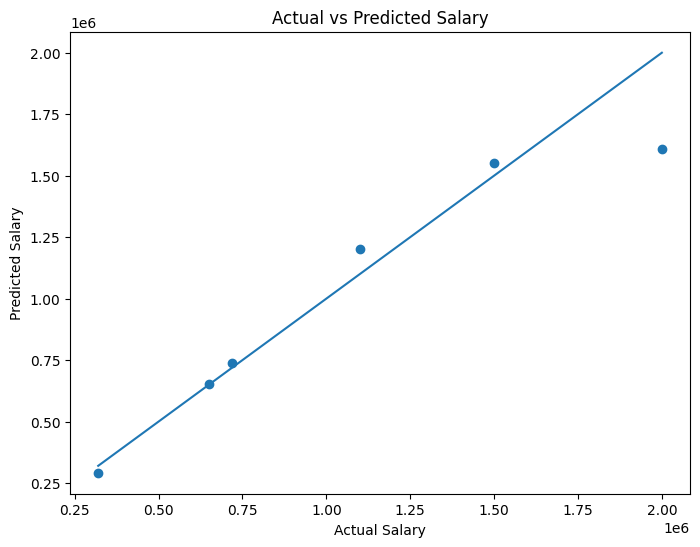

In [150]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [151]:
#seeing what is the error.That is how our model predicts.

error = y_test - y_pred
new = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Error': error})
new.head()

,Actual,Predicted,Error
9,1500000,1.552383e+06,-52382.705759
27,2000000,1.606669e+06,393330.502568
8,720000,7.361084e+05,-16108.433291
22,1100000,1.200054e+06,-100053.963907
0,320000,2.919093e+05,28090.721661
